<a href="https://colab.research.google.com/github/8Dis-like/UCLALearning/blob/main/MuJoCo_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Welcome to MuJoCo tutorial for C163/263A**

In this tutorial, we will load a [Q8 bot](https://github.com/EricYufengWu/q8bot?tab=readme-ov-file) in MuJoCo and

# **Install MJC**

In [ ]:
# Install MuJoCo (only needed once per fresh environment)
!pip install mujoco

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 21.6 MB/s eta 0:00:00


# **Convert URDF to MJCF**

In [ ]:
import os

os.environ["MUJOCO_GL"] = "egl"

import mujoco
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------------
# Configuration
# --------------------------------------------------------
# Path to your URDF file (relative to current working dir)
urdf_path = "/content/urdf/urdf/Q8bot.urdf"

# Output MJCF XML filename
mjcf_path = "Q8bot.xml"

# --------------------------------------------------------
# Load URDF and convert to MJCF
# --------------------------------------------------------
# MuJoCo can directly load URDF files via MjModel.from_xml_path
# Top-level XML tag must be <robot> for URDF.
model = mujoco.MjModel.from_xml_path(urdf_path)

# Save the compiled model back to MJCF XML format.
# This uses the internal "last loaded XML" representation.
# Ref: official MuJoCo-based tools that use mj_saveLastXML for URDF→MJCF conversion. :contentReference[oaicite:2]{index=2}
mujoco.mj_saveLastXML(mjcf_path, model)

print(f"Saved MJCF model to: {os.path.abspath(mjcf_path)}")


ValueError: ParseXML: Error opening file '/content/urdf/urdf/Q8bot.urdf': No such file or directory

# **Load & Render**

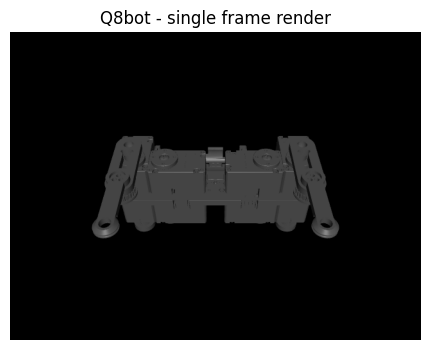

In [ ]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 1) Load model & data (if not already loaded)
# --------------------------------------------------------
mjcf_path = "/content/Q8bot.xml"
model = mujoco.MjModel.from_xml_path(mjcf_path)
data  = mujoco.MjData(model)

# --------------------------------------------------------
# 2) Create an offscreen renderer
# --------------------------------------------------------
# width, height can be changed as you like
renderer = mujoco.Renderer(model, width=640, height=480)

# Optionally step the simulation a few times before rendering
for _ in range(100):
    mujoco.mj_step(model, data)

# Update scene and render one frame
renderer.update_scene(data)
img = renderer.render()

# --------------------------------------------------------
# 3) Show the rendered image in the notebook
# --------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Q8bot - single frame render")
plt.show()


# **Move a single leg**

In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"   # Set EGL before importing mujoco

import mujoco
import numpy as np
import math
import matplotlib.pyplot as plt
import imageio
from IPython.display import HTML
from base64 import b64encode

# -------------------------------
# 1) Load model
# -------------------------------
mjcf_path = "/content/Q8bot.xml"
model = mujoco.MjModel.from_xml_path(mjcf_path)
data  = mujoco.MjData(model)

print("nq:", model.nq, "nv:", model.nv, "njnt:", model.njnt)

# -------------------------------
# 2) Choose joint to animate
# -------------------------------
joint_name = "Revolute 74"
j_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, joint_name)
qpos_addr = model.jnt_qposadr[j_id]
print("Animating joint:", joint_name, "id:", j_id, "qpos index:", qpos_addr)

# -------------------------------
# 3) Simulation / rendering setup
# -------------------------------
duration  = 7.0
framerate = 60.0

dt = model.opt.timestep
num_steps = int(duration / dt)
steps_per_frame = max(1, int(1.0 / (framerate * dt)))

frames = []

mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)

with mujoco.Renderer(model, width=640, height=480) as renderer:
    for step in range(num_steps):
        t = step * dt

        amplitude = 0.4
        freq      = 0.5
        data.qpos[qpos_addr] = amplitude * math.sin(2.0 * math.pi * freq * t)

        mujoco.mj_forward(model, data)

        if step % steps_per_frame == 0:
            renderer.update_scene(data)
            pixels = renderer.render()
            frames.append(pixels)

print("Number of frames rendered:", len(frames))

# -------------------------------
# 4) Save video and display inline
# -------------------------------
video_path = "/content/q8bot_joint_motion.mp4"
imageio.mimsave(video_path, frames, fps=int(framerate))
print("Saved video to:", video_path)

mp4 = open(video_path, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="640" height="480" controls autoplay loop>
  <source src="{data_url}" type="video/mp4">
</video>
""")


nq: 8 nv: 8 njnt: 8
Animating joint: Revolute 74 id: 0 qpos index: 0
Number of frames rendered: 438
Saved video to: /content/q8bot_joint_motion.mp4


# **Move all joints**

In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"   # Set EGL before importing mujoco

import mujoco
import numpy as np
import math
import matplotlib.pyplot as plt
import imageio
from IPython.display import HTML
from base64 import b64encode

# ----------------------------------------
# 1) Load Q8bot model
# ----------------------------------------
mjcf_path = "/content/Q8bot.xml"  # adjust if needed
model = mujoco.MjModel.from_xml_path(mjcf_path)
data  = mujoco.MjData(model)

print("nq:", model.nq, "nv:", model.nv, "njnt:", model.njnt)

# ----------------------------------------
# 2) Define leg joints (hips + knees)
# ----------------------------------------
hip_joint_names  = ["Revolute 74", "Revolute 75", "Revolute 76", "Revolute 77"]
knee_joint_names = ["Revolute 78", "Revolute 79", "Revolute 80", "Revolute 81"]

hip_ids  = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
            for name in hip_joint_names]
knee_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
            for name in knee_joint_names]

hip_qpos_addrs  = [model.jnt_qposadr[jid] for jid in hip_ids]
knee_qpos_addrs = [model.jnt_qposadr[jid] for jid in knee_ids]

print("Hip qpos indices :", hip_qpos_addrs)
print("Knee qpos indices:", knee_qpos_addrs)

# ----------------------------------------
# 3) Phase + base offset for each leg
# ----------------------------------------
# Each leg gets a phase offset
leg_phases = [0.0, 0.5 * math.pi, 1.0 * math.pi, 1.5 * math.pi]

# Each hip gets a base angle offset (in radians)
# Here: leg 0 and 2 start at 180 deg, leg 1 and 3 start at 0 deg
hip_base_offsets = [0.0, 0.0, math.pi, math.pi]

# ----------------------------------------
# 4) Simulation & rendering settings
# ----------------------------------------
duration  = 7.0      # seconds
framerate = 60.0     # Hz

dt = model.opt.timestep
num_steps = int(duration / dt)
steps_per_frame = max(1, int(1.0 / (framerate * dt)))

frames = []

# Joint motion parameters
hip_amp   = 0.4      # rad, swing amplitude for hips
knee_base = 0.5      # rad, base bend for knees
knee_amp  = 0.25     # rad, modulation amplitude
freq      = 0.5      # Hz, gait frequency

# Reset state
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)

# ----------------------------------------
# 5) Simulate and record frames
# ----------------------------------------
with mujoco.Renderer(model, width=640, height=480) as renderer:
    for step in range(num_steps):
        t = step * dt

        for i in range(4):
            phase = leg_phases[i]

            # Hip joint motion: base offset + swing
            hip_angle = hip_base_offsets[i] + hip_amp * math.sin(
                2.0 * math.pi * freq * t + phase
            )
            data.qpos[hip_qpos_addrs[i]] = hip_angle

            # Knee joint motion (unchanged)
            knee_angle = knee_base + knee_amp * math.sin(
                2.0 * math.pi * freq * t + phase + math.pi / 4.0
            )
            data.qpos[knee_qpos_addrs[i]] = knee_angle

        mujoco.mj_forward(model, data)

        if step % steps_per_frame == 0:
            renderer.update_scene(data)
            pixels = renderer.render()
            frames.append(pixels)

print("Number of frames rendered:", len(frames))

# ----------------------------------------
# 6) Save to video and display inline
# ----------------------------------------
video_path = "/content/q8bot_all_legs_motion_offset.mp4"
imageio.mimsave(video_path, frames, fps=int(framerate))
print("Saved video to:", video_path)

mp4 = open(video_path, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="640" height="480" controls autoplay loop>
  <source src="{data_url}" type="video/mp4">
</video>
""")


nq: 8 nv: 8 njnt: 8
Hip qpos indices : [np.int32(0), np.int32(2), np.int32(4), np.int32(6)]
Knee qpos indices: [np.int32(7), np.int32(5), np.int32(1), np.int32(3)]
Number of frames rendered: 438
Saved video to: /content/q8bot_all_legs_motion_offset.mp4
